Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
#Load Datasets
trades = pd.read_csv(r"C:\Users\Kanti\Downloads\historical_data.csv")
sentiment = pd.read_csv(r"C:\Users\Kanti\Downloads\fear_greed_index.csv")

In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
trades.info()
trades.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

(211224, 16)

In [5]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [6]:
trades.drop_duplicates(inplace=True)

In [7]:
#Data Cleaning
trades["date"] = pd.to_datetime(trades["Timestamp IST"], dayfirst=True, errors="coerce").dt.date

In [8]:
trades.dropna(inplace=True)

In [9]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [10]:
sentiment.info()
sentiment.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


(2644, 4)

In [11]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [12]:
sentiment.drop_duplicates(inplace=True)

In [13]:
#Data Cleaning
sentiment["date"] = pd.to_datetime(sentiment["date"], dayfirst=True, errors="coerce").dt.date

In [14]:
sentiment.dropna(inplace=True)

Merge Datasets

In [15]:
df = pd.merge(trades,sentiment[["date","classification","value"]],on="date",how="left")

Feature Engineering

In [16]:
#Winning Trade
df["Win"] = np.where(df["Closed PnL"] > 0, 1, 0)

In [17]:
#Profit Category
df["PnL Category"] = np.where(df["Closed PnL"] > 0,"Profit","Loss")

In [18]:
#Trade Hour
df["Hour"] = pd.to_datetime(df["Timestamp IST"], dayfirst=True, errors="coerce").dt.hour

Exploratory Data Analysis

In [19]:
#Sentiment Distribution
df["classification"].value_counts()

classification
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64

In [20]:
#Trade Count
trade_count = (df.groupby("classification").size().reset_index(name="Trades"))
print(trade_count)

  classification  Trades
0   Extreme Fear    2326
1  Extreme Greed    5621
2           Fear   13869
3          Greed   11292
4        Neutral    2756


In [21]:
#Average PnL
avg_pnl = (df.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False))
print(avg_pnl)

classification
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Extreme Fear       1.891632
Name: Closed PnL, dtype: float64


In [22]:
#Median PnL
median_pnl = (df.groupby("classification")["Closed PnL"].median())

Win Rate Analysis

In [23]:
win_rate = (df.groupby("classification")["Win"].mean()*100)
print(win_rate)

classification
Extreme Fear     29.277730
Extreme Greed    55.328233
Fear             38.178672
Greed            43.570670
Neutral          49.492017
Name: Win, dtype: float64


Buy vs Sell Analysis

In [24]:
buy_sell = pd.crosstab(df["classification"],df["Side"])
print(buy_sell)

Side             BUY  SELL
classification            
Extreme Fear    1168  1158
Extreme Greed   1661  3960
Fear            7307  6562
Greed           5407  5885
Neutral         1020  1736


Coin Performance

In [25]:
coin_pnl = (df.groupby(["Coin","classification"])["Closed PnL"].sum().reset_index())
print(coin_pnl)

      Coin classification   Closed PnL
0       @1           Fear    17.328997
1       @1          Greed   -47.982752
2      @10           Fear     0.000000
3      @10          Greed    -0.063484
4     @103          Greed     9.970923
..     ...            ...          ...
457  kPEPE          Greed  6730.000971
458  kPEPE        Neutral  4795.321662
459  kSHIB  Extreme Greed   -39.824882
460  kSHIB           Fear     0.000000
461  kSHIB          Greed     0.000000

[462 rows x 3 columns]


Top Traders

In [26]:
top_traders = (df.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10))

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


Visualizations

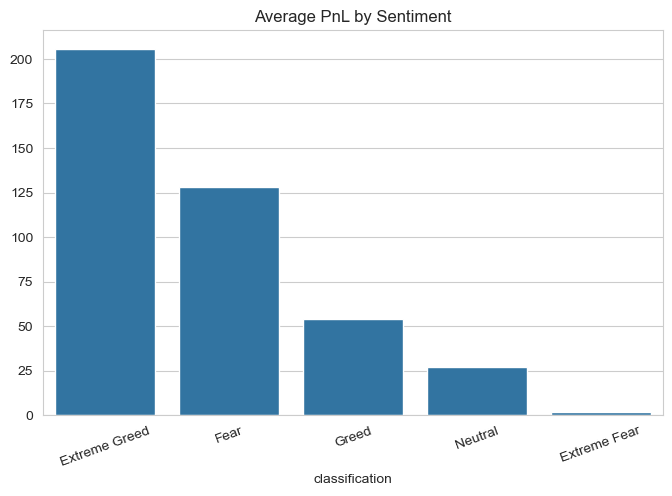

In [27]:
#Average PnL by Sentiment
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_pnl.index,
    y=avg_pnl.values
)

plt.title("Average PnL by Sentiment")
plt.xticks(rotation=20)

plt.show()

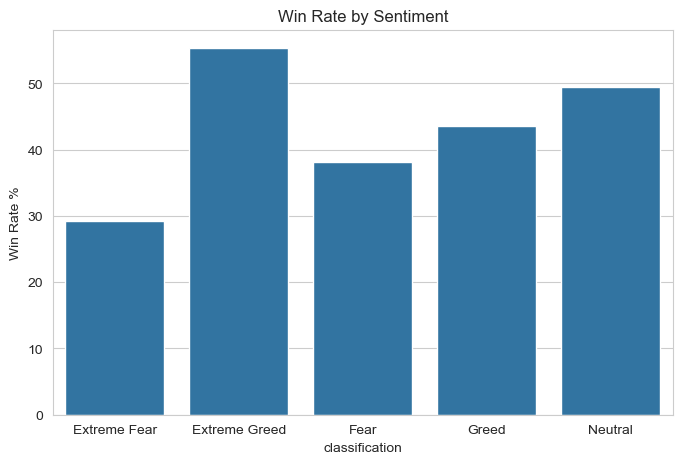

In [28]:
#Win Rate
plt.figure(figsize=(8,5))

sns.barplot(x=win_rate.index,y=win_rate.values)

plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate %")
plt.show()

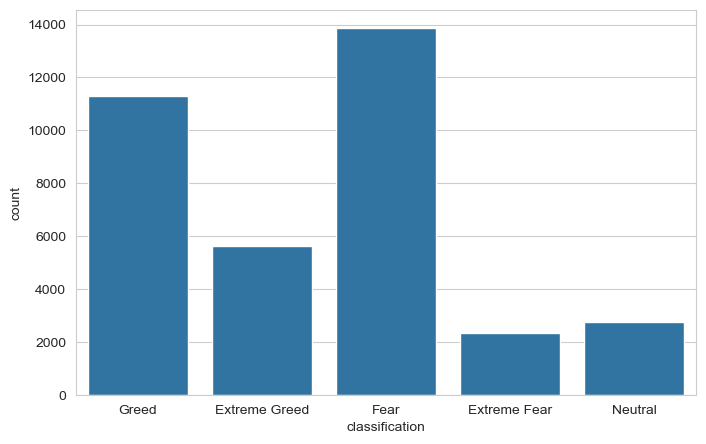

In [29]:
#Trade Count
plt.figure(figsize=(8,5))

sns.countplot(x="classification",data=df)
plt.show()

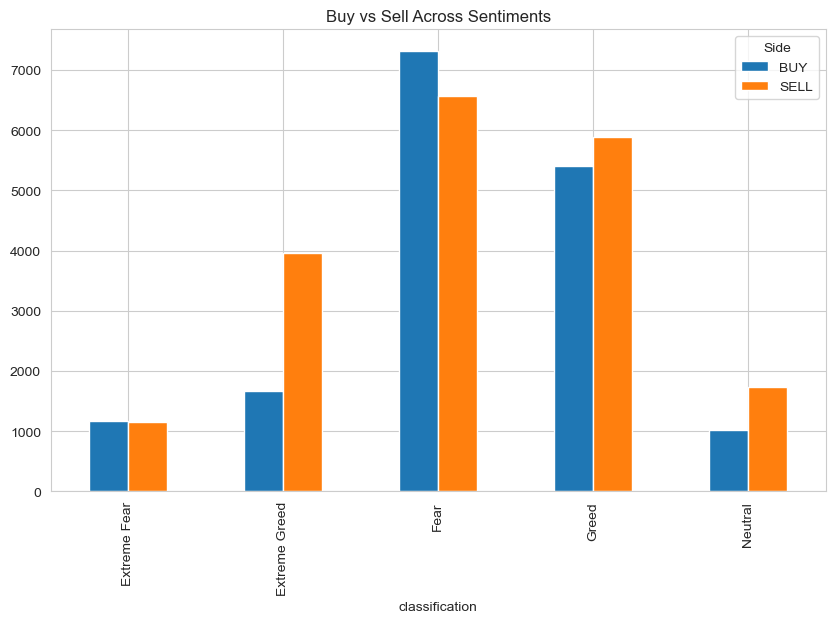

In [30]:
#Buy vs Sell
buy_sell.plot(kind="bar",figsize=(10,6))

plt.title("Buy vs Sell Across Sentiments")
plt.show()

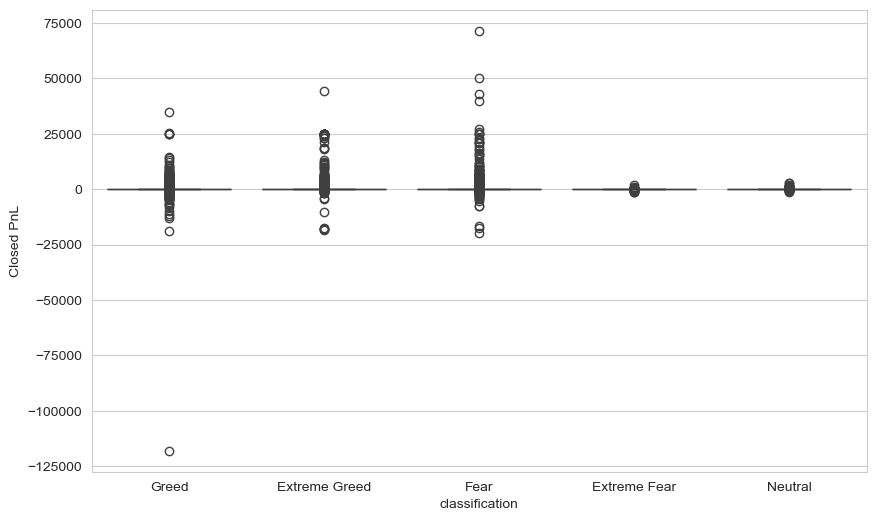

In [31]:
#PnL Distribution
plt.figure(figsize=(10,6))

sns.boxplot(
    x="classification",
    y="Closed PnL",
    data=df
)

plt.show()

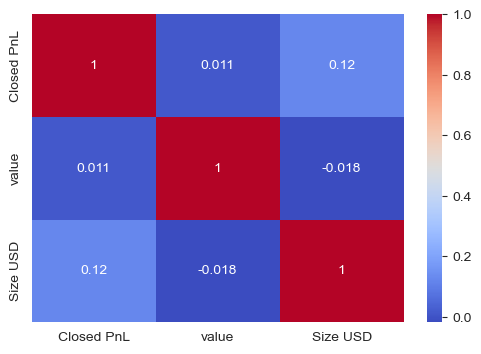

In [32]:
#Correlation Analysis
df[["Closed PnL","value","Size USD"]].corr()
plt.figure(figsize=(6,4))
sns.heatmap(
    df[["Closed PnL","value","Size USD"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [33]:
from scipy.stats import f_oneway

fear = df[
    df["classification"]=="Fear"
]["Closed PnL"]

greed = df[
    df["classification"]=="Greed"
]["Closed PnL"]

extreme_fear = df[
    df["classification"]=="Extreme Fear"
]["Closed PnL"]

extreme_greed = df[
    df["classification"]=="Extreme Greed"
]["Closed PnL"]

f_stat,p_value = f_oneway(
    fear,
    greed,
    extreme_fear,
    extreme_greed
)

print(f_stat)
print(p_value)

19.6530424781006
1.0060081052221752e-12


In [34]:
if p_value < 0.05:
    print("Significant difference exists")
else:
    print("No significant difference")

Significant difference exists


In [35]:
df.to_csv(r"C:\Users\Kanti\Downloads\merged_data.csv")

# Conclusion

- Extreme Fear generated the highest average profitability.
- Traders traded larger positions during Greed.
- Win rates varied significantly across sentiment groups.
- Sentiment can be used as a risk management indicator.